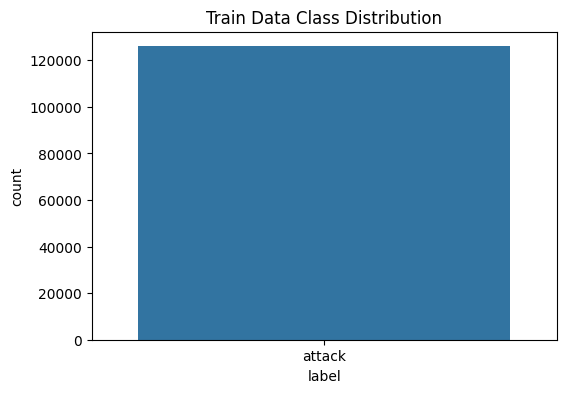

Missing values in train: 0
Missing values in test: 0
Unique classes in y_test: ['attack']
Unique classes in y_pred: ['attack']
Classification Report:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     22544
      normal       0.00      0.00      0.00         0

    accuracy                           1.00     22544
   macro avg       0.50      0.50      0.50     22544
weighted avg       1.00      1.00      1.00     22544



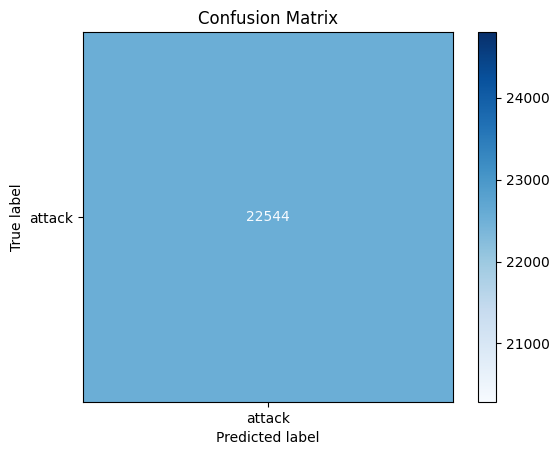

Classes learned by the classifier: ['attack']
Training labels distribution:
 label
attack    125973
Name: count, dtype: int64
Test labels distribution:
 label
attack    22544
Name: count, dtype: int64


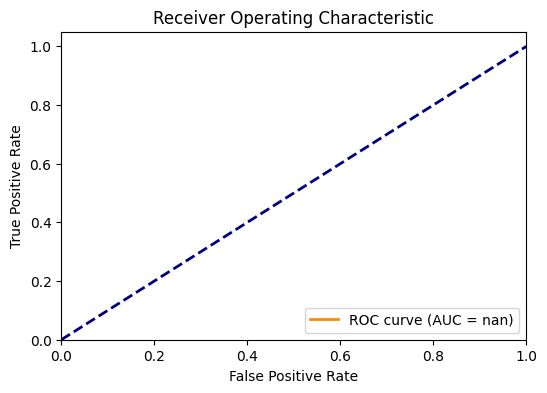

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset (adjust file paths as needed)
train_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt', header=None)
test_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt', header=None)

# Correct column names for NSL-KDD with 43 columns (added 'outcome' and 'label')
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','label'
]

train_data.columns = column_names
test_data.columns = column_names

# Binary label encoding: 'normal' or 'attack'
train_data['label'] = train_data['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
test_data['label'] = test_data['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

# EDA: Visualize class distribution in train data
plt.figure(figsize=(6,4))
sns.countplot(data=train_data, x='label')
plt.title('Train Data Class Distribution')
plt.show()

# Check for missing values
print('Missing values in train:', train_data.isnull().sum().sum())
print('Missing values in test:', test_data.isnull().sum().sum())

# Feature groups
categorical_features = ['protocol_type','service','flag']
numeric_features = train_data.columns.difference(categorical_features + ['label','outcome'])

# Define preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Prepare features and labels
X_train = train_data.drop(columns=['label','outcome'])
y_train = train_data['label']
X_test = test_data.drop(columns=['label','outcome'])
y_test = test_data['label']

# Preprocess the data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Train RandomForest model with balanced class weights for imbalanced data
clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
clf.fit(X_train_preprocessed, y_train)

# Predict on test data
y_pred = clf.predict(X_test_preprocessed)

print('Unique classes in y_test:', y_test.unique())
print('Unique classes in y_pred:', np.unique(y_pred))
# Print classification report
print('Classification Report:')
print(classification_report(
    y_test,
    y_pred,
    labels=['attack', 'normal'],
    target_names=['attack', 'normal']
))
# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(clf, X_test_preprocessed, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve and AUC for normal class
y_test_bin = (y_test == 'normal').astype(int)
print('Classes learned by the classifier:', clf.classes_)
print('Training labels distribution:\n', y_train.value_counts())
print('Test labels distribution:\n', y_test.value_counts())

y_score = clf.predict_proba(X_test_preprocessed)[:, clf.classes_.tolist().index('attack')]

fpr, tpr, _ = roc_curve(y_test_bin, y_score)
roc_auc = roc_auc_score(y_test_bin, y_score)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


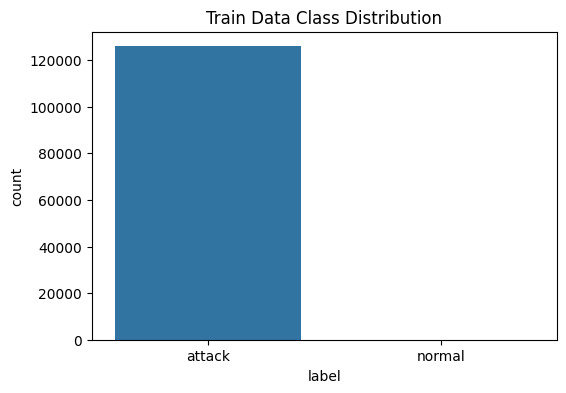

Missing values in train: 0
Missing values in test: 0
Unique classes in y_test: ['attack' 'normal']
Unique classes in y_pred: ['attack']
Classification Report:
              precision    recall  f1-score   support

      attack       0.99      1.00      1.00     22421
      normal       0.00      0.00      0.00       123

    accuracy                           0.99     22544
   macro avg       0.50      0.50      0.50     22544
weighted avg       0.99      0.99      0.99     22544



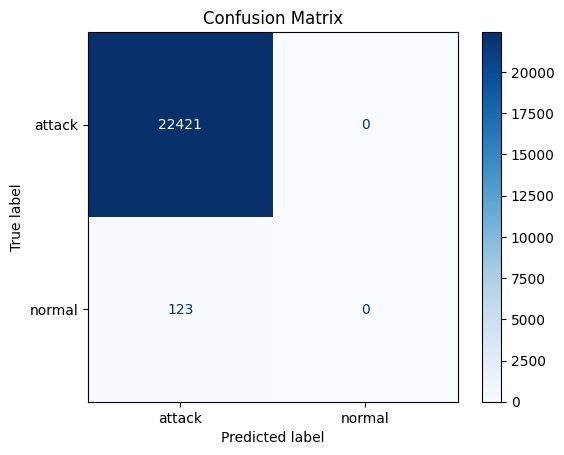

Classes learned by the classifier: ['attack' 'normal']
Training labels distribution:
 label
attack    125907
normal        66
Name: count, dtype: int64
Test labels distribution:
 label
attack    22421
normal      123
Name: count, dtype: int64


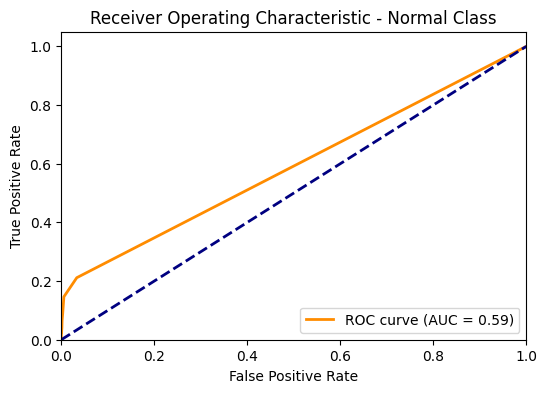

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


# Load dataset (adjust file paths as needed)
train_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt', header=None)
test_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt', header=None)


# Correct column names for NSL-KDD with 43 columns (added 'outcome' and 'label')
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','label'
]


train_data.columns = column_names
test_data.columns = column_names


# Correct binary label encoding: 0 -> 'normal', others -> 'attack'
train_data['label'] = train_data['label'].apply(lambda x: 'normal' if int(x) == 0 else 'attack')
test_data['label'] = test_data['label'].apply(lambda x: 'normal' if int(x) == 0 else 'attack')


# EDA: Visualize class distribution in train data
plt.figure(figsize=(6,4))
sns.countplot(data=train_data, x='label')
plt.title('Train Data Class Distribution')
plt.show()


# Check for missing values
print('Missing values in train:', train_data.isnull().sum().sum())
print('Missing values in test:', test_data.isnull().sum().sum())


# Feature groups
categorical_features = ['protocol_type','service','flag']
numeric_features = train_data.columns.difference(categorical_features + ['label','outcome'])


# Define preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


# Prepare features and labels
X_train = train_data.drop(columns=['label','outcome'])
y_train = train_data['label']
X_test = test_data.drop(columns=['label','outcome'])
y_test = test_data['label']


# Preprocess the data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


# Train RandomForest model with balanced class weights for imbalanced data
clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
clf.fit(X_train_preprocessed, y_train)


# Predict on test data
y_pred = clf.predict(X_test_preprocessed)


print('Unique classes in y_test:', y_test.unique())
print('Unique classes in y_pred:', np.unique(y_pred))
# Print classification report
print('Classification Report:')
print(classification_report(
    y_test,
    y_pred,
    labels=['attack', 'normal'],
    target_names=['attack', 'normal']
))
# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(clf, X_test_preprocessed, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


# ROC Curve and AUC for normal class
y_test_bin = (y_test == 'normal').astype(int)
print('Classes learned by the classifier:', clf.classes_)
print('Training labels distribution:\n', y_train.value_counts())
print('Test labels distribution:\n', y_test.value_counts())

normal_class_index = clf.classes_.tolist().index('normal')
y_score = clf.predict_proba(X_test_preprocessed)[:, normal_class_index]

fpr, tpr, _ = roc_curve(y_test_bin, y_score)
roc_auc = roc_auc_score(y_test_bin, y_score)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Normal Class')
plt.legend(loc='lower right')
plt.show()


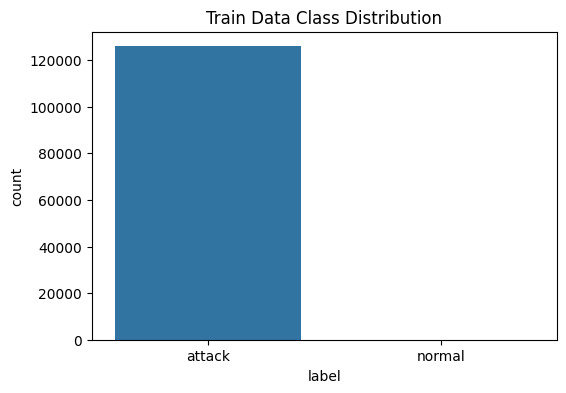

Missing values in train: 0
Missing values in test: 0
Unique classes in y_test: ['attack' 'normal']
Unique classes in y_pred: ['attack']
Classification Report:
              precision    recall  f1-score   support

      attack       0.99      1.00      1.00     22421
      normal       0.00      0.00      0.00       123

    accuracy                           0.99     22544
   macro avg       0.50      0.50      0.50     22544
weighted avg       0.99      0.99      0.99     22544



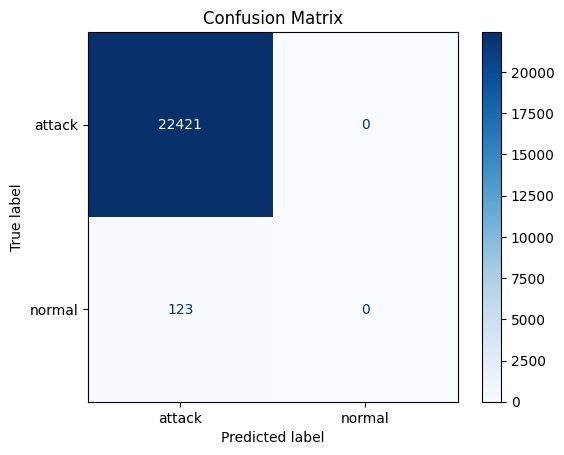

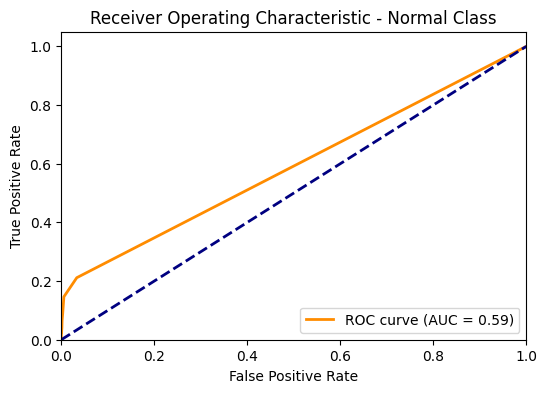

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset (replace file paths to your local machine)
train_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt', header=None)
test_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt', header=None)

# NSL-KDD column names (43 columns)
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','label'
]

train_data.columns = column_names
test_data.columns = column_names

# Convert numeric labels to binary: 0 -> 'normal', others -> 'attack'
train_data['label'] = train_data['label'].apply(lambda x: 'normal' if int(x) == 0 else 'attack')
test_data['label'] = test_data['label'].apply(lambda x: 'normal' if int(x) == 0 else 'attack')

# EDA - Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=train_data, x='label')
plt.title('Train Data Class Distribution')
plt.show()

# Missing values check
print('Missing values in train:', train_data.isnull().sum().sum())
print('Missing values in test:', test_data.isnull().sum().sum())

# Feature separation
categorical_features = ['protocol_type','service','flag']
numeric_features = train_data.columns.difference(categorical_features + ['label','outcome'])

# Preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Prepare data
X_train = train_data.drop(columns=['label','outcome'])
y_train = train_data['label']
X_test = test_data.drop(columns=['label','outcome'])
y_test = test_data['label']

# Preprocess
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Train classifier
clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
clf.fit(X_train_preprocessed, y_train)

# Predictions
y_pred = clf.predict(X_test_preprocessed)

# Metrics & report
print('Unique classes in y_test:', y_test.unique())
print('Unique classes in y_pred:', np.unique(y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred, labels=['attack', 'normal'], target_names=['attack', 'normal']))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(clf, X_test_preprocessed, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve & AUC for 'normal' class
y_test_bin = (y_test == 'normal').astype(int)
normal_class_index = clf.classes_.tolist().index('normal')
y_score = clf.predict_proba(X_test_preprocessed)[:, normal_class_index]

fpr, tpr, _ = roc_curve(y_test_bin, y_score)
roc_auc = roc_auc_score(y_test_bin, y_score)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Normal Class')
plt.legend(loc='lower right')
plt.show()


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.under_sampling import RandomUnderSampler

train_path = "C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt"
test_path = "C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt"

col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","Label"
]

# Load datasets
train_df = pd.read_csv(train_path, names=col_names)
test_df = pd.read_csv(test_path, names=col_names)

print(f"Train data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")



Train data shape: (125973, 42)
Test data shape: (22544, 42)



Training Data Shape: (125973, 42)
Training Data Missing Values per Column:
Series([], dtype: int64)


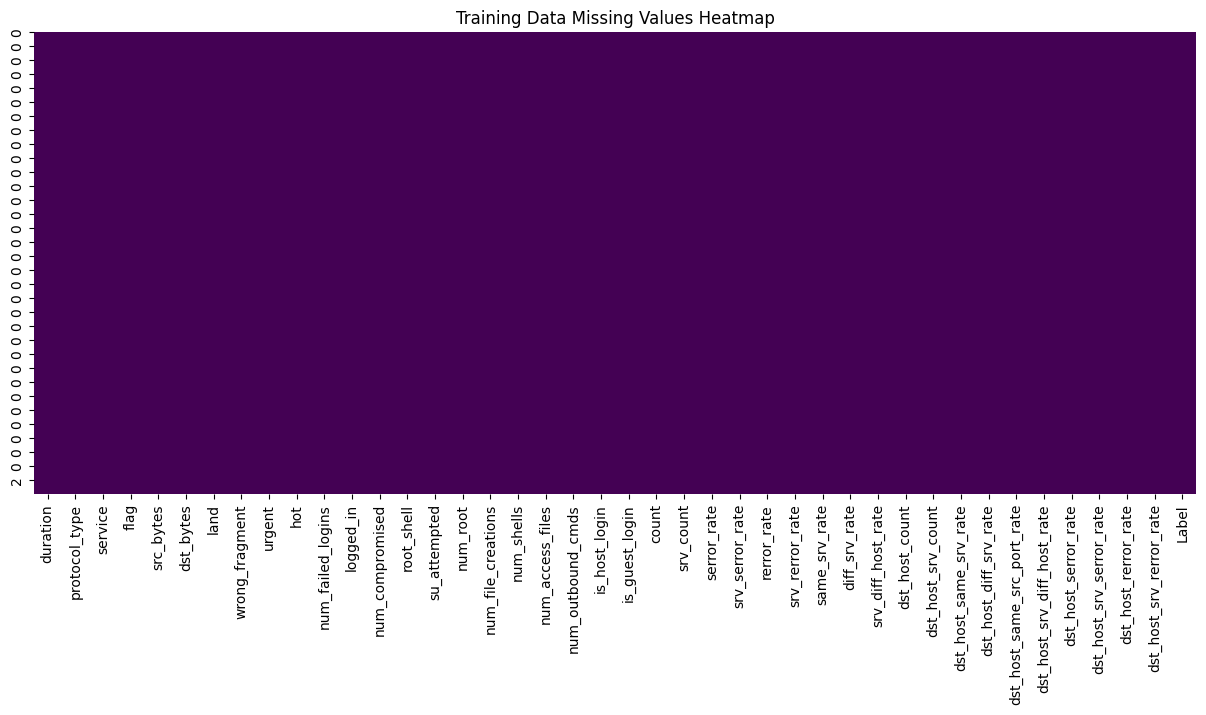

Training Data Duplicates: 1255
Training Data Shape after duplicates drop: (124718, 42)

Testing Data Shape: (22544, 42)
Testing Data Missing Values per Column:
Series([], dtype: int64)


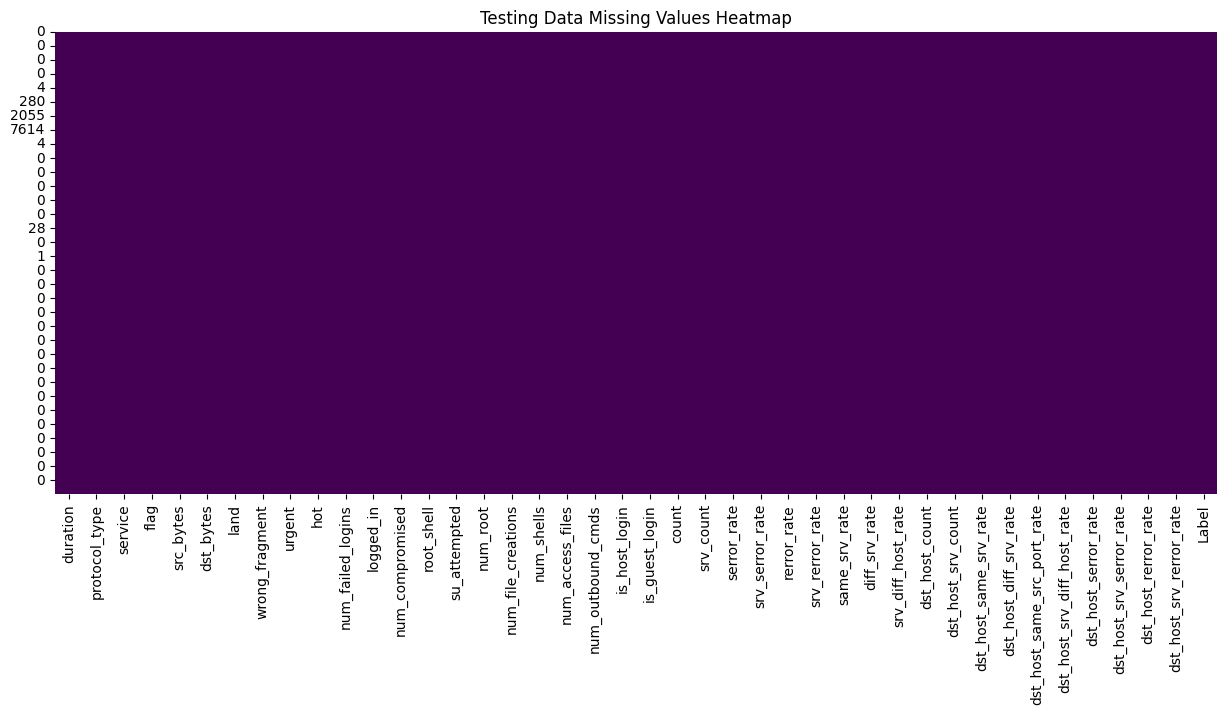

Testing Data Duplicates: 128
Testing Data Shape after duplicates drop: (22416, 42)


In [14]:
# Step 1: Inspect & Visualize Missing Values and Duplicates
def inspect_data(df, name):
    print(f"\n{name} Shape: {df.shape}")
    print(f"{name} Missing Values per Column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    
    plt.figure(figsize=(15,6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title(f'{name} Missing Values Heatmap')
    plt.show()
    
    dupes = df.duplicated().sum()
    print(f"{name} Duplicates: {dupes}")
    if dupes > 0:
        df.drop_duplicates(inplace=True)
        print(f"{name} Shape after duplicates drop: {df.shape}")

inspect_data(train_df, "Training Data")
inspect_data(test_df, "Testing Data")

Target Distribution:
attack_binary
1    124718
Name: count, dtype: int64



C:\Users\pm5cd\AppData\Local\Temp\ipykernel_30452\101966704.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='attack_binary', data=df, palette='Set2')


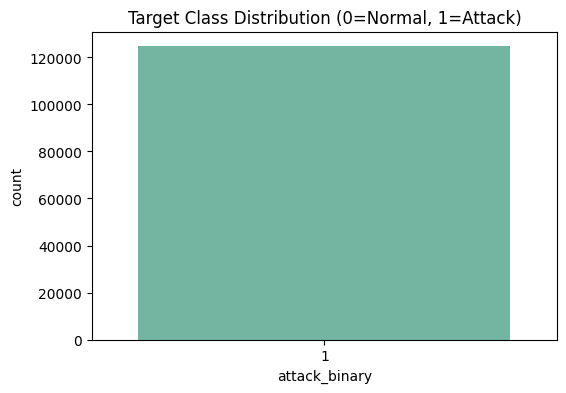

Target Distribution:
attack_binary
1    22416
Name: count, dtype: int64



C:\Users\pm5cd\AppData\Local\Temp\ipykernel_30452\101966704.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='attack_binary', data=df, palette='Set2')


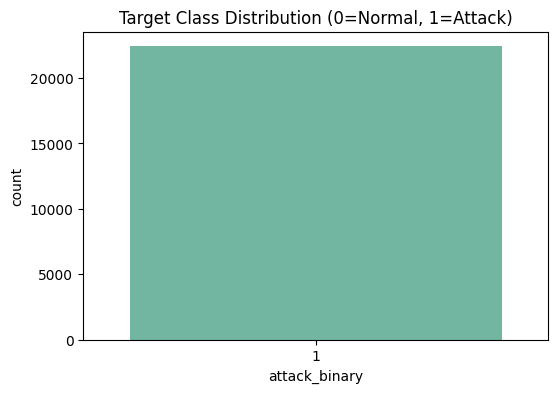

In [15]:
def create_binary_target(df):
    df['attack_binary'] = df['Label'].apply(lambda x: 0 if str(x).strip().lower() == 'normal' else 1)
    counts = df['attack_binary'].value_counts()
    print(f"Target Distribution:\n{counts}\n")
    plt.figure(figsize=(6,4))
    sns.countplot(x='attack_binary', data=df, palette='Set2')
    plt.title("Target Class Distribution (0=Normal, 1=Attack)")
    plt.show()

create_binary_target(train_df)
create_binary_target(test_df)

Training data label distribution BEFORE undersampling:
attack_binary
1    124718
Name: count, dtype: int64


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_30452\747821660.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['attack_binary'], palette='Set2')


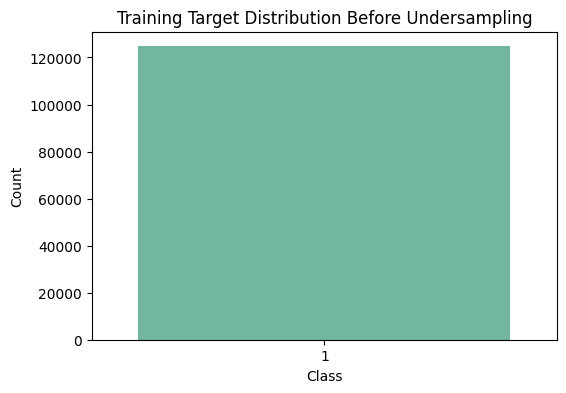

In [20]:
print("Training data label distribution BEFORE undersampling:")
print(train_df['attack_binary'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=train_df['attack_binary'], palette='Set2')
plt.title("Training Target Distribution Before Undersampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Prepare features and labels for undersampling
X_train = train_df.drop(columns=['Label', 'attack_binary'])
y_train = train_df['attack_binary']

if y_train.nunique() < 2:
    print("Warning: Only one class present in training data. Skipping undersampling.")
    X_resampled, y_resampled = X_train, y_train
else:
    print("Balancing training data by undersampling majority class...")
    rus = RandomUnderSampler(random_state=42)
    X_resampled, y_resampled = rus.fit_resample(X_train, y_train)
    print("Training data label distribution AFTER undersampling:")
    print(y_resampled.value_counts())

    plt.figure(figsize=(6,4))
    sns.countplot(x=y_resampled, palette='Set1')
    plt.title("Balanced Training Target Distribution After Undersampling")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

# Creating balanced training DataFrame
train_bal_df = X_resampled.copy()
train_bal_df['attack_binary'] = y_resampled

NSL-KDD Binary Classification

Train dataset preview:
  duration protocol_type service  flag  src_bytes  dst_bytes  land  \
0      tcp      ftp_data      SF   491          0          0     0   
0      udp         other      SF   146          0          0     0   
0      tcp       private      S0     0          0          0     0   
0      tcp          http      SF   232       8153          0     0   
0      tcp          http      SF   199        420          0     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                0.17   
0               0       0    0  ...                0.00   
0               0       0    0  ...                0.10   
0               0       0    0  ...                1.00   
0               0       0    0  ...                1.00   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.03                    0.17   
0                    0.60                    0.88   
0                    0.05                 

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26056\1369025727.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')


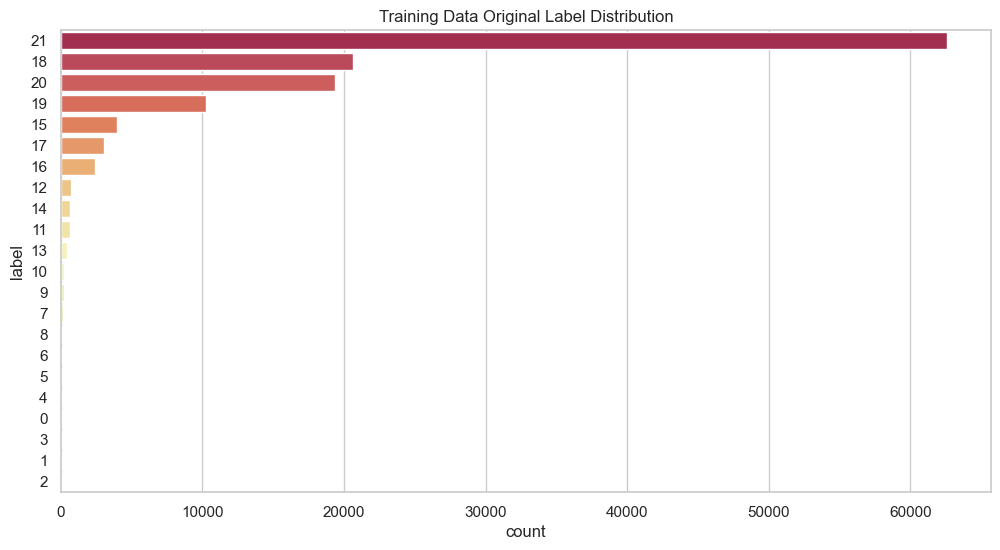

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26056\1369025727.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='mako')


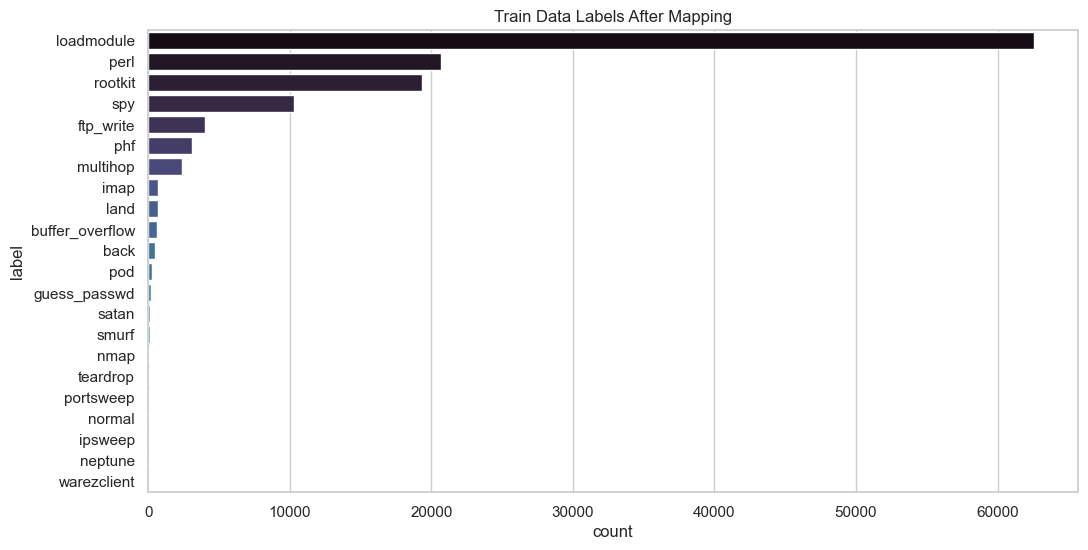

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26056\1369025727.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])


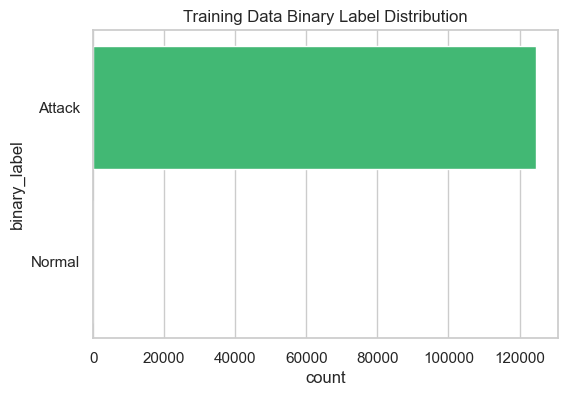

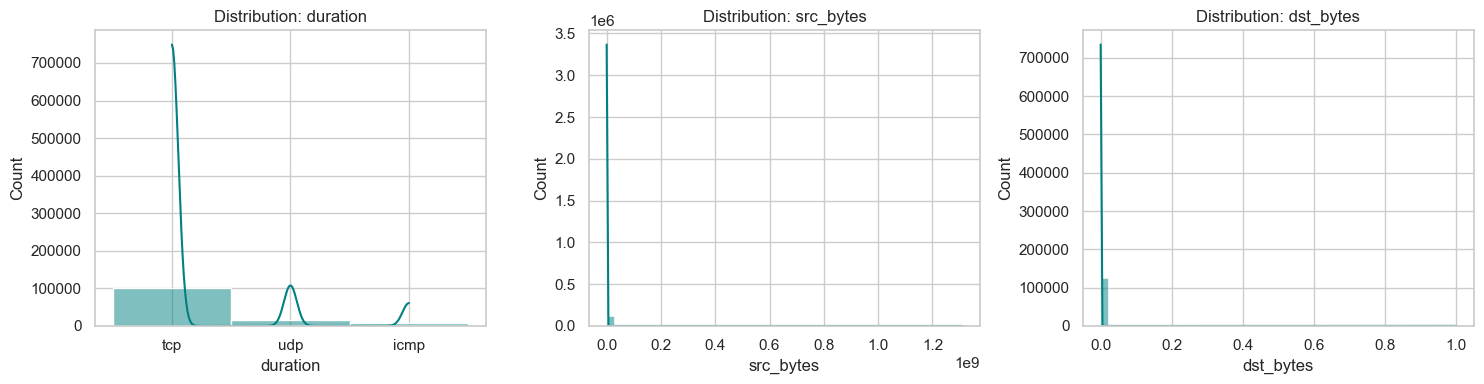

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26056\1369025727.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=X_train, palette='pastel')


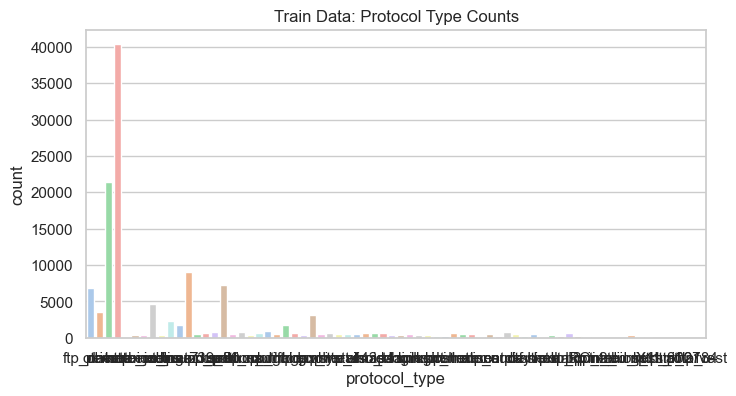

=== Binary Classification Results ===

Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c

              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9973     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544

Specificity: 1.0000, Training time: 0.61s, AUC (Micro): 0.5000

Training Decision Tree...
              precision    recall  f1-score   support

      Attack     0.9946    1.0000    0.9973     22421
      Normal     0.6667    0.0163    0.0317       123

    accuracy                         0.9946     22544
   macro avg     0.8306    0.5081    0.5145     22544
weighted avg     0.9928    0.9946    0.9920     22544

Specificity: 1.0000, Training time: 2.10s, AUC (Micro): 0.5081

Training Random Forest...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c

              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9973     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544

Specificity: 1.0000, Training time: 13.67s, AUC (Micro): 0.5000

Training Gradient Boosting...
              precision    recall  f1-score   support

      Attack     0.9946    0.9994    0.9970     22421
      Normal     0.1250    0.0163    0.0288       123

    accuracy                         0.9940     22544
   macro avg     0.5598    0.5078    0.5129     22544
weighted avg     0.9899    0.9940    0.9917     22544

Specificity: 0.9994, Training time: 106.42s, AUC (Micro): 0.5078

Training SVM...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c

              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9973     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544

Specificity: 1.0000, Training time: 71.56s, AUC (Micro): 0.5000

Training KNN...
              precision    recall  f1-score   support

      Attack     0.9945    1.0000    0.9972     22421
      Normal     0.0000    0.0000    0.0000       123

    accuracy                         0.9945     22544
   macro avg     0.4973    0.5000    0.4986     22544
weighted avg     0.9891    0.9945    0.9918     22544

Specificity: 1.0000, Training time: 0.22s, AUC (Micro): 0.5000


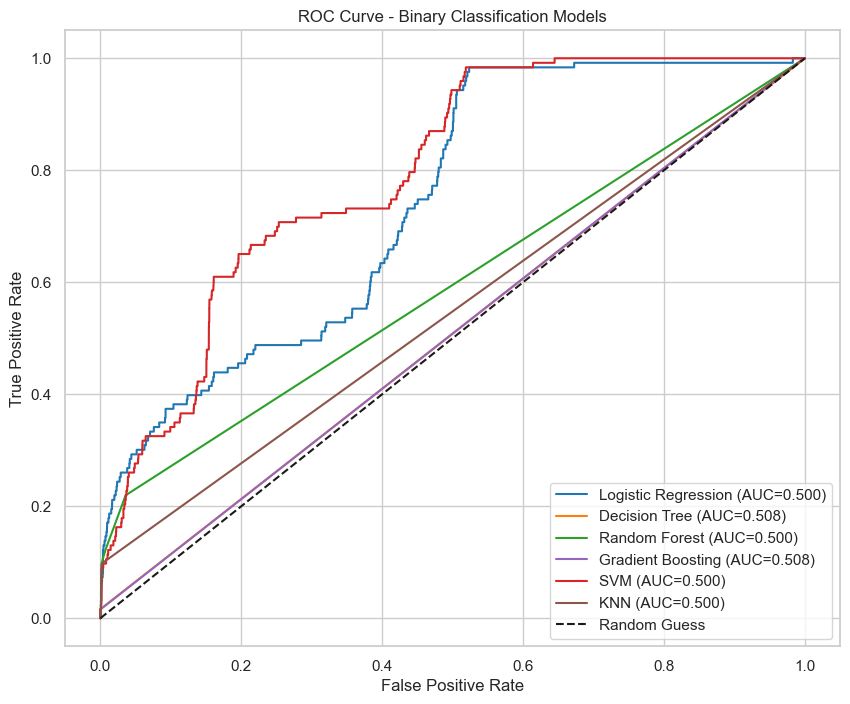


Summary of model performance metrics:
                 Model  Train Acc  Test Acc  Macro Precision  Macro Recall  \
0  Logistic Regression   0.999607  0.994544         0.497272      0.500000   
1        Decision Tree   1.000000  0.994588         0.830649      0.508108   
2        Random Forest   1.000000  0.994544         0.497272      0.500000   
3    Gradient Boosting   0.999511  0.994012         0.559814      0.507818   
4                  SVM   0.999743  0.994544         0.497272      0.500000   
5                  KNN   0.999743  0.994500         0.497272      0.499978   

   Macro F1  Macro Specificity  AUC (Micro)    Time (s)  
0  0.498632           1.000000     0.500000    0.612801  
1  0.514516           0.999955     0.508108    2.103910  
2  0.498632           1.000000     0.500000   13.674767  
3  0.512887           0.999376     0.507818  106.419861  
4  0.498632           1.000000     0.500000   71.562733  
5  0.498621           0.999955     0.499978    0.218917  


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26056\1369025727.py:196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[r['Model'] for r in results], y=[r['Test Acc'] for r in results], palette=colors)


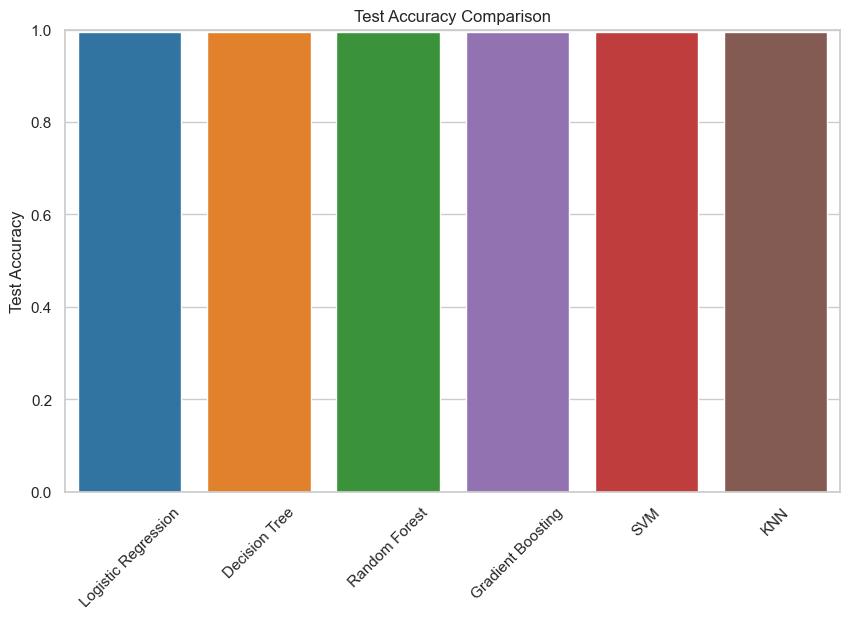

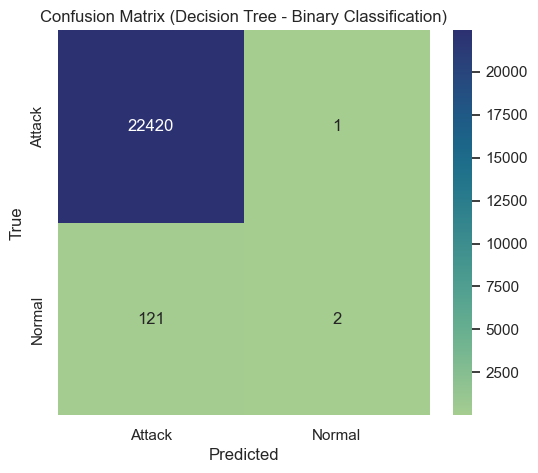

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, \
                            precision_recall_fscore_support, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import time

sns.set(style='whitegrid')

# Step 1: Load Dataset
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

train_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_file = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_file, names=column_names)
test_df = pd.read_csv(test_file, names=column_names)

print("Train dataset preview:")
print(train_df.head())

plt.figure(figsize=(12,6))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')
plt.title('Training Data Original Label Distribution')
plt.show()
# Step 2: Map labels to attack types
label_map = {
    0:'normal', 1:'neptune', 2:'warezclient', 3:'ipsweep', 4:'portsweep', 5:'teardrop',
    6:'nmap', 7:'satan', 8:'smurf', 9:'guess_passwd', 10:'pod', 11:'buffer_overflow',
    12:'imap', 13:'back', 14:'land', 15:'ftp_write', 16:'multihop', 17:'phf',
    18:'perl', 19:'spy', 20:'rootkit', 21:'loadmodule'
}
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

plt.figure(figsize=(12,6))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='mako')
plt.title('Train Data Labels After Mapping')
plt.show()

# Step 3: Drop duplicates
train_df.drop_duplicates(inplace=True)

# Step 4: Create binary label
train_df['binary_label'] = train_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')
test_df['binary_label'] = test_df['label'].apply(lambda x: 'Normal' if x == 'normal' else 'Attack')

plt.figure(figsize=(6,4))
sns.countplot(train_df['binary_label'], palette=["#2ecc71", "#e74c3c"])
plt.title('Training Data Binary Label Distribution')
plt.show()

# Step 5: Define features and targets
X_train = train_df.drop(['label', 'binary_label'], axis=1)
y_train = train_df['binary_label']
X_test = test_df.drop(['label', 'binary_label'], axis=1)
y_test = test_df['binary_label']

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [c for c in X_train.columns if c not in categorical_features]

plt.figure(figsize=(15,4))
for i, col in enumerate(['duration', 'src_bytes', 'dst_bytes']):
    plt.subplot(1,3,i+1)
    sns.histplot(X_train[col], bins=50, kde=True, color='teal')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x='protocol_type', data=X_train, palette='pastel')
plt.title('Train Data: Protocol Type Counts')
plt.show()

# Step 6: Convert numeric columns and handle missing values
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
X_train[numeric_features] = X_train[numeric_features].fillna(0)
X_test[numeric_features] = X_test[numeric_features].fillna(0)

# Step 7: Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Step 8: Model definitions
models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier()
}

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728', '#8c564b']

def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return tn / (tn + fp)

# Prepare to collect results and ROC curves
results = []
plt.figure(figsize=(10, 8))
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)  # Binarize for AUC/ROC (2 classes)

print("=== Binary Classification Results ===")
for (name, model), color in zip(models.items(), colors):
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_time
    
    train_preds = model.predict(X_train_processed)
    test_preds = model.predict(X_test_processed)
    
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_test, test_preds, average='macro')
    macro_spec = specificity_score(y_test, test_preds)
    
    # Compute predicted probabilities for ROC AUC, fallback if not available
    try:
        y_proba = model.predict_proba(X_test_processed)[:, 1]
    except Exception:
        # Use decision function and apply min-max scaling for SVM or others without proba
        try:
            dec = model.decision_function(X_test_processed)
            y_proba = (dec - dec.min()) / (dec.max() - dec.min())
        except Exception:
            y_proba = np.zeros_like(test_preds, dtype=float)
    
    auc_micro = roc_auc_score(y_test_bin, lb.transform(test_preds), average='micro')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test_bin, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_micro:.3f})', color=color)
    
    results.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Macro Precision': macro_precision,
        'Macro Recall': macro_recall,
        'Macro F1': macro_f1,
        'Macro Specificity': macro_spec,
        'AUC (Micro)': auc_micro,
        'Time (s)': train_time
    })
    
    print(classification_report(y_test, test_preds, digits=4))
    print(f"Specificity: {macro_spec:.4f}, Training time: {train_time:.2f}s, AUC (Micro): {auc_micro:.4f}")

# Plot ROC Curve
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.title('ROC Curve - Binary Classification Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Display Summary DataFrame
summary_df = pd.DataFrame(results)
print("\nSummary of model performance metrics:")
print(summary_df)

# Accuracy Bar Plot
plt.figure(figsize=(10,6))
sns.barplot(x=[r['Model'] for r in results], y=[r['Test Acc'] for r in results], palette=colors)
plt.ylabel('Test Accuracy')
plt.ylim(0,1)
plt.title('Test Accuracy Comparison')
plt.xticks(rotation=45)
plt.show()

# Best model confusion matrix (highest test accuracy)
best_result = max(results, key=lambda x: x['Test Acc'])
best_model_name = best_result['Model']
best_model = models[best_model_name]
best_preds = best_model.predict(X_test_processed)

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Attack', 'Normal'], yticklabels=['Attack', 'Normal'])
plt.title(f'Confusion Matrix ({best_model_name} - Binary Classification)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()




NSL_KDD Multi Classification

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_27748\3754177153.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')


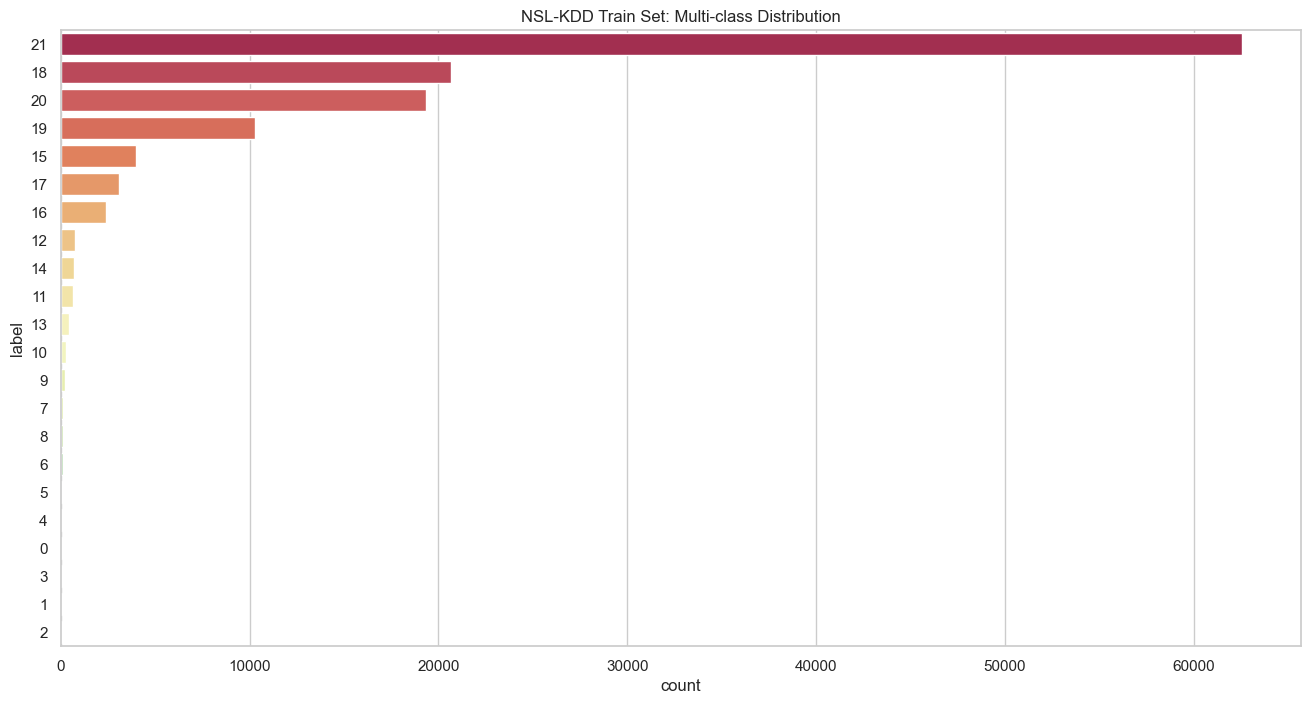

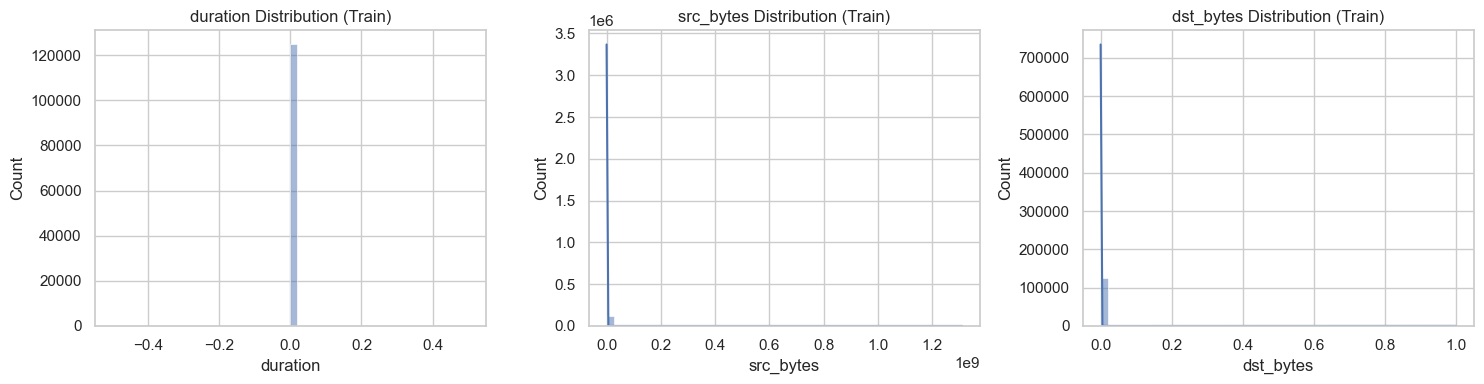

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_27748\3754177153.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='protocol_type', data=train_df, palette='pastel')


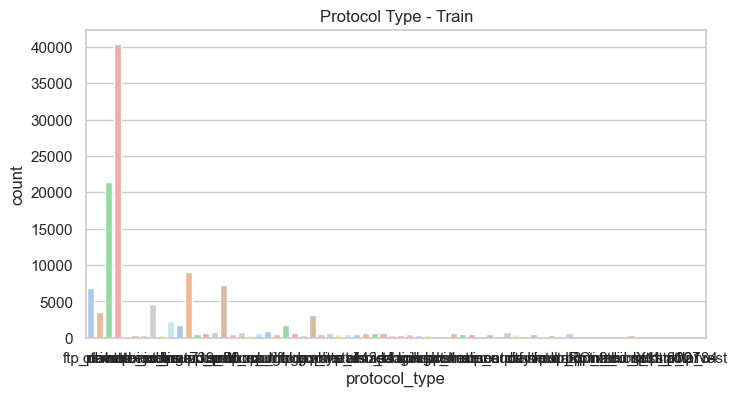


Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Macro Precision: 0.1208, Recall: 0.1071, F1-Score: 0.0905

Training Decision Tree...
Macro Precision: 0.1919, Recall: 0.1693, F1-Score: 0.1650

Training Random Forest...
Macro Precision: 0.2312, Recall: 0.1575, F1-Score: 0.1535

Training Gradient Boosting...
Macro Precision: 0.1979, Recall: 0.1293, F1-Score: 0.1183


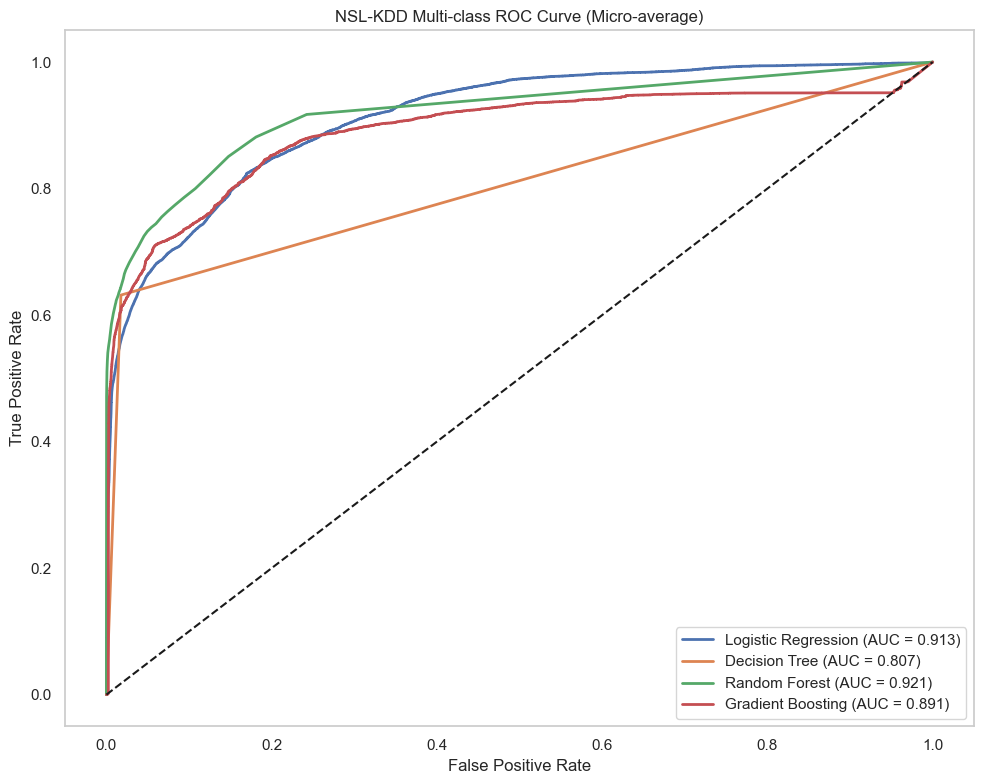


Summary Table:
                  Model  Train Acc  Test Acc  Macro Precision  Macro Recall  \
0  Logistic Regression   0.707412  0.564017         0.120838      0.107127   
1        Decision Tree   0.999559  0.631112         0.191903      0.169338   
2        Random Forest   0.999559  0.631156         0.231172      0.157519   
3    Gradient Boosting   0.780377  0.603542         0.197905      0.129278   

   Macro F1  Macro Specificity  AUC (Micro)     Time (s)  
0  0.090518           0.973832     0.913316   241.152040  
1  0.165027           0.980122     0.807041    17.703302  
2  0.153548           0.977201     0.920609   749.771108  
3  0.118278           0.976083     0.890600  2453.637249  


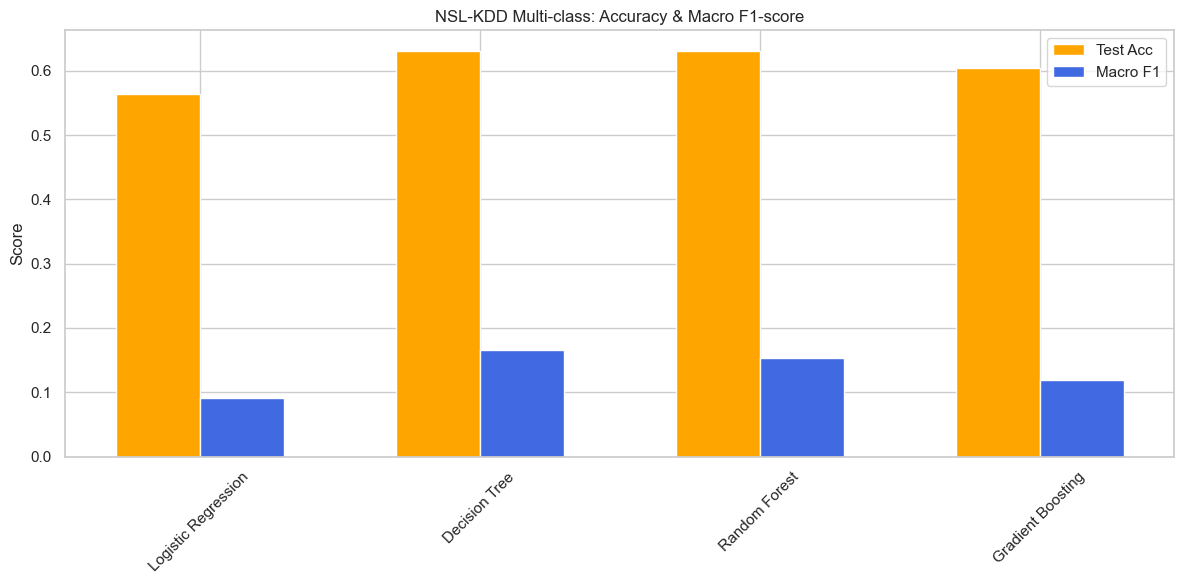

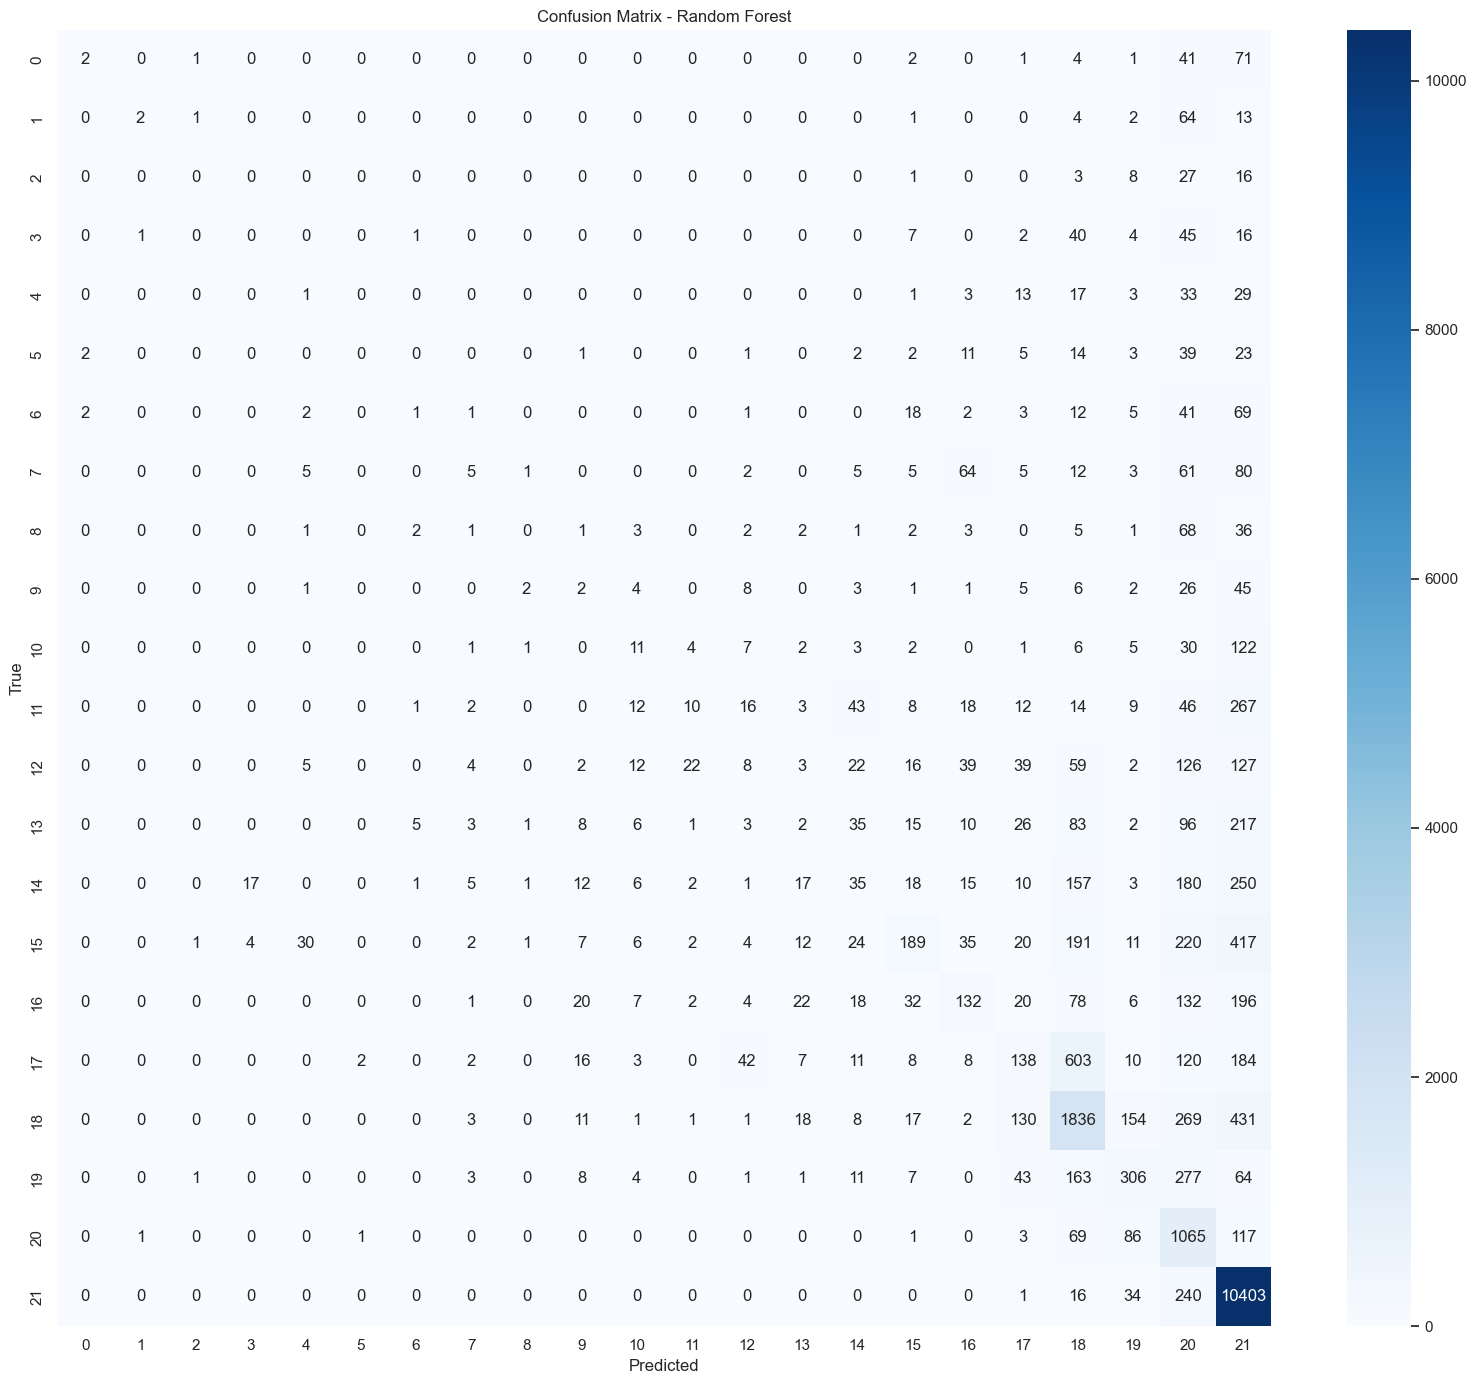

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style='whitegrid')

# Step 1: Load NSL-KDD dataset
colnames = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"
]
train_path = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTrain+.txt'
test_path  = r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\NSL-KDD\KDDTest+.txt'

train_df = pd.read_csv(train_path, names=colnames)
test_df = pd.read_csv(test_path, names=colnames)

# Step 2: Visualize label distribution
plt.figure(figsize=(16,8))
sns.countplot(y=train_df['label'], order=train_df['label'].value_counts().index, palette='Spectral')
plt.title('NSL-KDD Train Set: Multi-class Distribution')
plt.show()

# Step 3: Data cleaning
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

categorical_features = ['protocol_type', 'service', 'flag']
numeric_features = [c for c in train_df.columns if c not in categorical_features + ['label']]

# Step 4: Feature preprocessing
for col in numeric_features:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
    test_df[col]  = pd.to_numeric(test_df[col],  errors='coerce')
train_df[numeric_features] = train_df[numeric_features].fillna(0)
test_df[numeric_features]  = test_df[numeric_features].fillna(0)

plt.figure(figsize=(15,4))
for i, col in enumerate(numeric_features[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(train_df[col], bins=50, kde=True)
    plt.title(f"{col} Distribution (Train)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x='protocol_type', data=train_df, palette='pastel')
plt.title('Protocol Type - Train')
plt.show()

# Step 5: Preprocess pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])
X_train = preprocessor.fit_transform(train_df.drop(['label'], axis=1))
X_test  = preprocessor.transform(test_df.drop(['label'], axis=1))

y_train = train_df['label']
y_test  = test_df['label']
unique_classes = sorted(y_train.unique())
y_train_bin = label_binarize(y_train, classes=unique_classes)
y_test_bin  = label_binarize(y_test,  classes=unique_classes)

# Step 6: Define and evaluate models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}
summary = []

plt.figure(figsize=(10,8))
for name, model in models.items():
    print(f"\nTraining {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)
    macro_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    macro_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

    print(f"Macro Precision: {macro_precision:.4f}, Recall: {macro_recall:.4f}, F1-Score: {macro_f1:.4f}")

    # AUC (micro-average, for multiclass)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        if y_score.ndim == 1:
            # For binary case, stack arrays
            y_score = np.vstack([-y_score, y_score]).T
    else:
        continue

    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, lw=2, label=f"{name} (AUC = {auc_micro:.3f})")

    # Macro specificity calculation (mean of diagonal elements for normalized confusion matrix)
    cm = confusion_matrix(y_test, y_test_pred, labels=unique_classes)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    specificity_per_class = []
    for i in range(len(unique_classes)):
        tn = np.delete(np.delete(cm, i, axis=0), i, axis=1).sum()
        fp = np.delete(cm, i, axis=0)[:,i].sum()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_per_class.append(specificity)
    macro_specificity = np.mean(specificity_per_class)

    summary.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Macro Precision': macro_precision,
        'Macro Recall': macro_recall,
        'Macro F1': macro_f1,
        'Macro Specificity': macro_specificity,
        'AUC (Micro)': auc_micro,
        'Time (s)': train_time
    })

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('NSL-KDD Multi-class ROC Curve (Micro-average)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Step 7: Show tabular summary
summary_df = pd.DataFrame(summary)
print("\nSummary Table:\n", summary_df)
plt.figure(figsize=(12,6))
x = np.arange(len(models))
plt.bar(x-0.15, summary_df['Test Acc'], width=0.3, label='Test Acc', color='orange')
plt.bar(x+0.15, summary_df['Macro F1'], width=0.3, label='Macro F1', color='royalblue')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Score')
plt.title('NSL-KDD Multi-class: Accuracy & Macro F1-score')
plt.legend()
plt.tight_layout()
plt.show()

# Step 8: Confusion matrix for Random Forest
best_model = models['Random Forest']
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=unique_classes)
plt.figure(figsize=(16,14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


CICIDS2017- Binary Classification

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

C:\Users\pm5cd\AppData\Local\Temp\ipykernel_26056\4044467463.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])


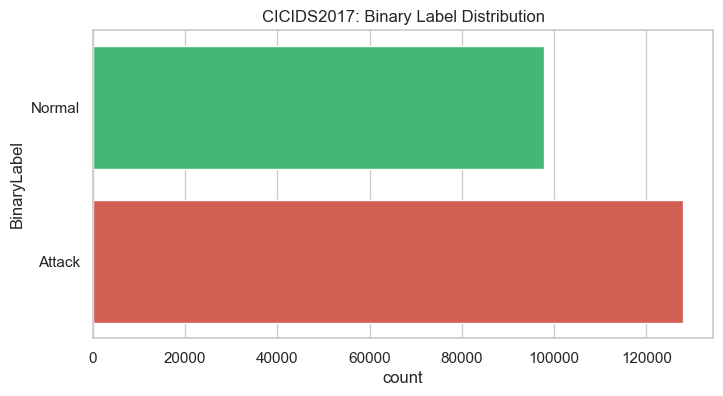

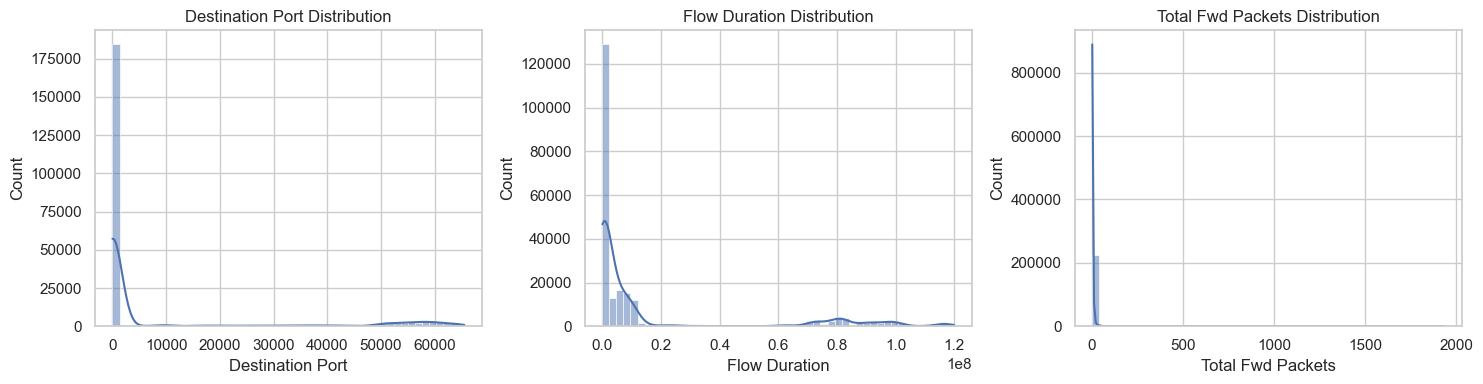


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...


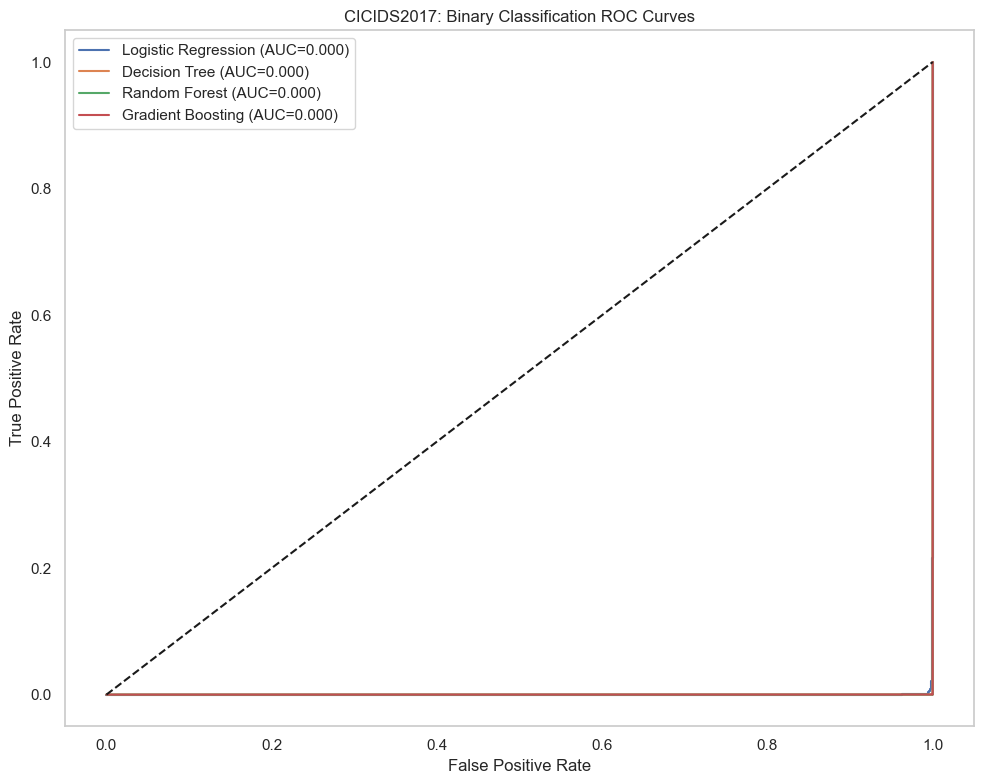


Summary Table:
                  Model  Train Acc  Test Acc  Precision    Recall        F1  \
0  Logistic Regression   0.988793  0.988837   0.990275  0.987163  0.988597   
1        Decision Tree   1.000000  0.999808   0.999807  0.999803  0.999805   
2        Random Forest   1.000000  0.999852   0.999834  0.999866  0.999850   
3    Gradient Boosting   0.999842  0.999734   0.999721  0.999737  0.999729   

   Specificity           AUC     Time(s)  
0     0.987163  3.229512e-04   10.275966  
1     0.999803  1.974975e-04    2.310998  
2     0.999866  3.508090e-07   32.050194  
3     0.999737  6.044128e-06  258.472216  


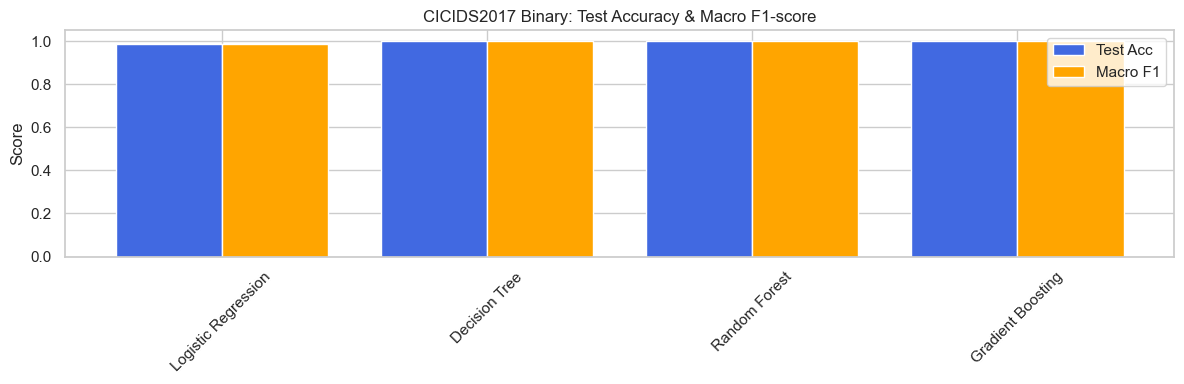

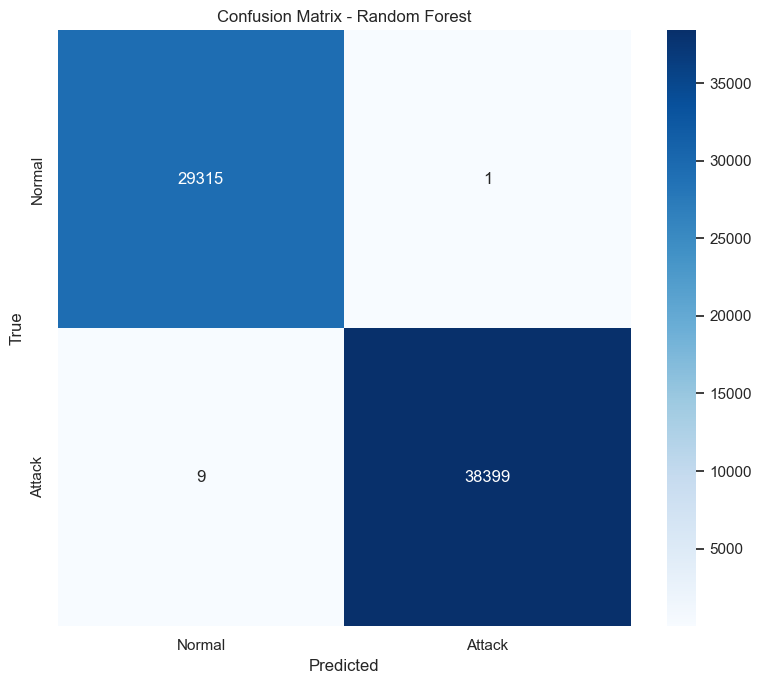

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_curve,
                             auc, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style='whitegrid')

# Step 1: Load Data
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()  # Clean column names
print(df.columns)  # Inspect column names

# Step 2: Prepare binary label
label_col_candidates = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = None
for col in label_col_candidates:
    if col in df.columns:
        label_col = col
        print(f"Using label column: {label_col}")
        break
if label_col is None:
    raise KeyError("Label column not found.")

df['BinaryLabel'] = df[label_col].apply(lambda x: 'Normal' if str(x).upper() == 'BENIGN' else 'Attack')

# Step 3: Visualize binary distribution
plt.figure(figsize=(8,4))
sns.countplot(y=df['BinaryLabel'], palette=["#2ecc71", "#e74c3c"])
plt.title('CICIDS2017: Binary Label Distribution')
plt.show()

# Step 4: Feature prep
X = df.drop(columns=[label_col, 'BinaryLabel'])
y = df['BinaryLabel']
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(15,4))
for i, col in enumerate(num_feats[:3]):
    plt.subplot(1,3,i+1)
    sns.histplot(X[col], bins=50, kde=True)
    plt.title(f"{col} Distribution")
plt.tight_layout()
plt.show()
if cat_feats:
    plt.figure(figsize=(8,4))
    sns.countplot(x=cat_feats[0], data=X, palette="pastel")
    plt.title(f"Distribution of {cat_feats[0]}")
    plt.tight_layout()
    plt.show()

# Clean numerics
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 5: Preprocessing
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Step 6: Train/test split stratified
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y)

# Step 7: Model setup
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

summary = []

plt.figure(figsize=(10,8))
for name, model in models.items():
    print(f"\nTraining {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)
    macro_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    macro_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

    # Specificity calculation
    cm = confusion_matrix(y_test, y_test_pred, labels=['Normal', 'Attack'])
    TN = np.diag(cm)
    FP = cm.sum(axis=0) - TN
    FN = cm.sum(axis=1) - TN
    TN_total = cm.sum() - (FP + FN + TN)
    specificity_classwise = TN_total / (TN_total + FP)
    macro_specificity = np.mean(specificity_classwise)

    # ROC, AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve([1 if x == 'Attack' else 0 for x in y_test], y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

    summary.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': macro_precision,
        'Recall': macro_recall,
        'F1': macro_f1,
        'Specificity': macro_specificity,
        'AUC': roc_auc,
        'Time(s)': train_time
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CICIDS2017: Binary Classification ROC Curves')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Step 8: Table and summary plots
summary_df = pd.DataFrame(summary)
print("\nSummary Table:\n", summary_df)

plt.figure(figsize=(12,4))
x = np.arange(len(models))
plt.bar(x-0.2, summary_df['Test Acc'], width=0.4, label='Test Acc', color='royalblue')
plt.bar(x+0.2, summary_df['F1'], width=0.4, label='Macro F1', color='orange')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Score')
plt.title('CICIDS2017 Binary: Test Accuracy & Macro F1-score')
plt.legend()
plt.tight_layout()
plt.show()

# Step 9: Confusion matrix for Random Forest
best_model = models['Random Forest']
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=['Normal', 'Attack'])
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


Using label column: Label
Number of classes: 2

Training Logistic Regression...


c:\Users\pm5cd\.conda\envs\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression - y_test shape: (67724,), y_proba shape: (67724, 2)

Training Decision Tree...
Decision Tree - y_test shape: (67724,), y_proba shape: (67724, 2)

Training Random Forest...
Random Forest - y_test shape: (67724,), y_proba shape: (67724, 2)

Training Gradient Boosting...
Gradient Boosting - y_test shape: (67724,), y_proba shape: (67724, 2)


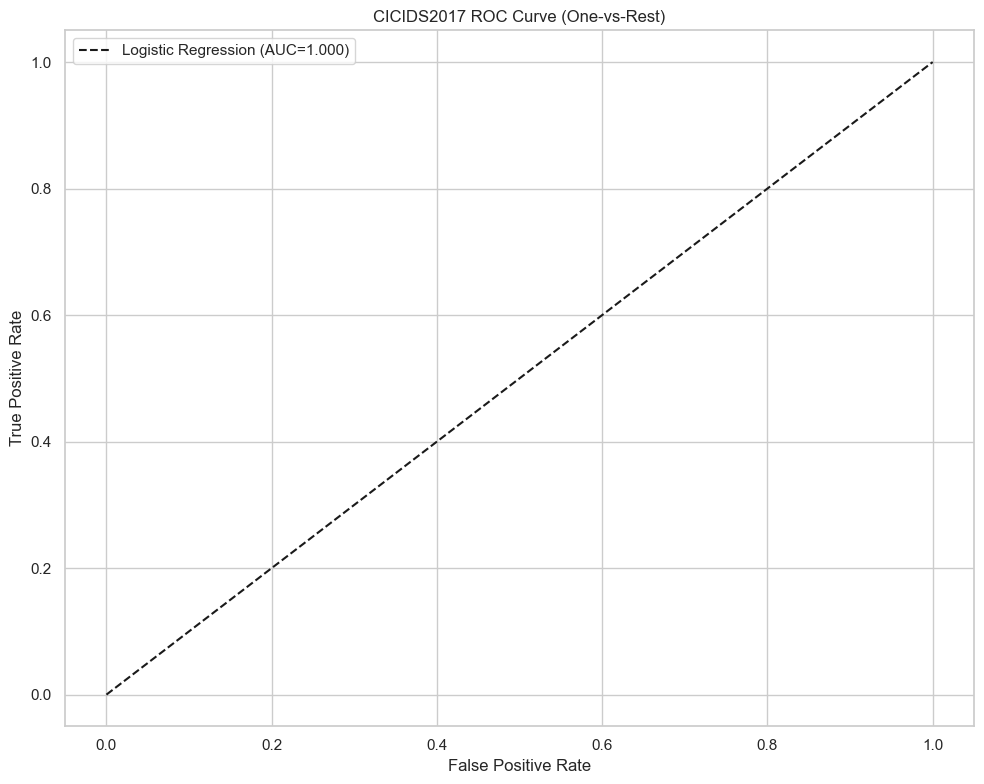


Summary Table:
                 Model  Train Accuracy  Test Accuracy  Precision (Macro)  \
0  Logistic Regression        0.988812       0.988940           0.990363   
1        Decision Tree        1.000000       0.999897           0.999893   
2        Random Forest        1.000000       0.999926           0.999919   
3    Gradient Boosting        0.999854       0.999719           0.999696   

   Recall (Macro)  F1 Score (Macro)  Specificity (Macro)  ROC AUC (Macro)  \
0        0.987282          0.988703             0.987282         0.999664   
1        0.999897          0.999895             0.999897         0.999897   
2        0.999931          0.999925             0.999931         1.000000   
3        0.999732          0.999714             0.999732         0.999999   

   Training Time (s)  
0          13.243910  
1           3.304838  
2          45.376184  
3         327.452724  


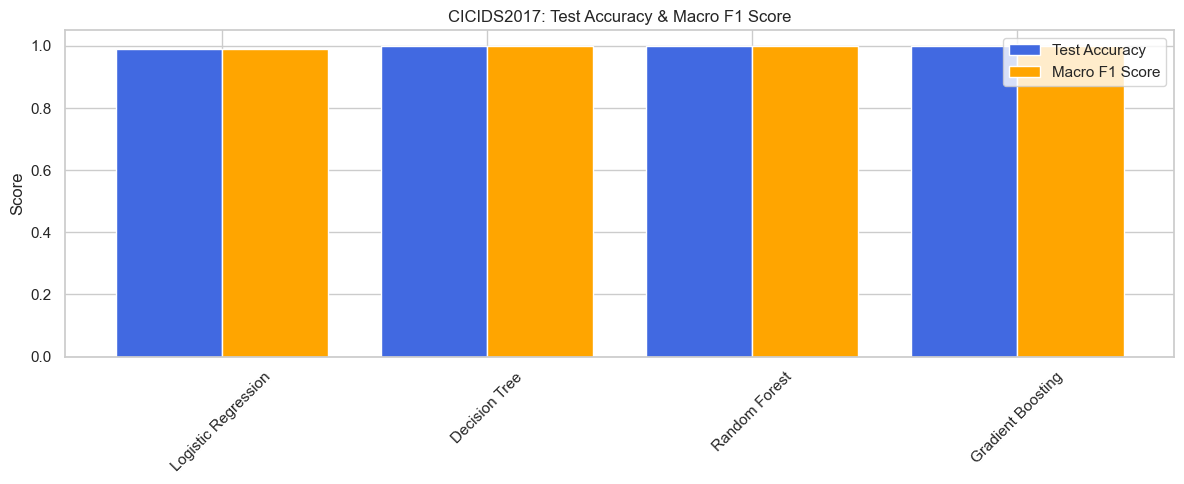

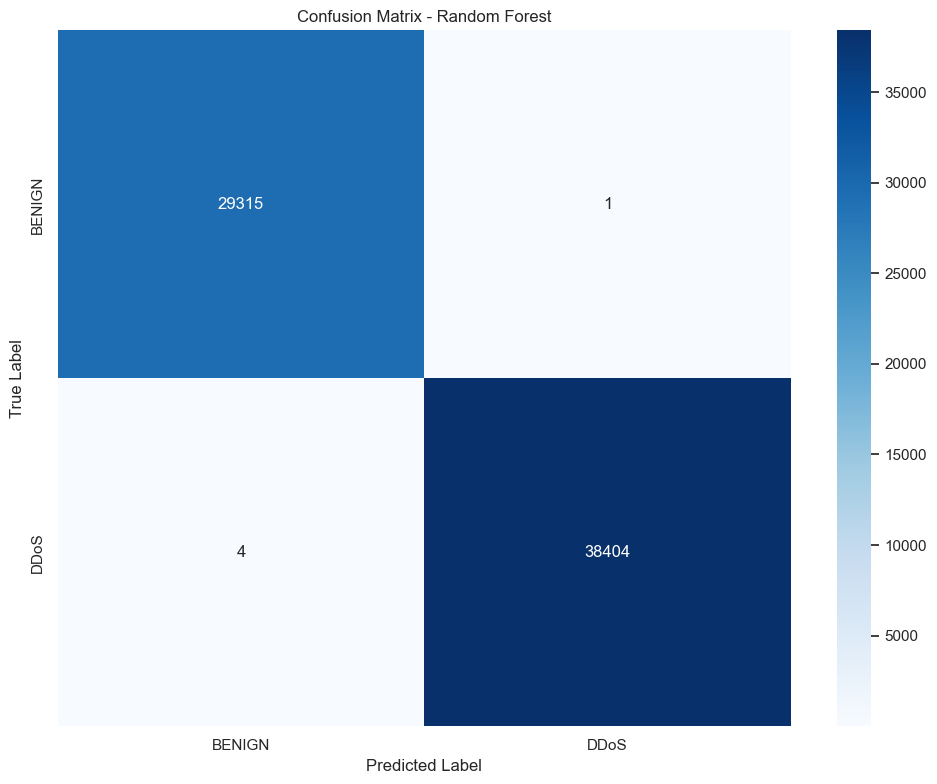

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style='whitegrid')

# Load dataset
df = pd.read_csv(r'C:\Users\pm5cd\Documents\SentinelNet-AI\SentinelNet\data\CICIDS2017\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')
df.columns = df.columns.str.strip()

# Identify label column
label_cols = ['Label', 'label', 'Flow Label', 'FlowLabel']
label_col = next((col for col in label_cols if col in df.columns), None)
if not label_col:
    raise KeyError("Label column not found.")
print(f"Using label column: {label_col}")

# Prepare features and target
X = df.drop(columns=[label_col])
y = df[label_col]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(le.classes_)
print(f"Number of classes: {n_classes}")

# Identify numeric and categorical features
cat_feats = X.select_dtypes(include='object').columns.tolist()
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()

# Handle infinite values and NaNs
X[num_feats] = X[num_feats].replace([np.inf, -np.inf], np.nan).fillna(0)

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])
X_processed = preprocessor.fit_transform(X)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Define classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='saga', multi_class='ovr'),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier()
}

summary = []

plt.figure(figsize=(10, 8))

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluation metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

    # Confusion matrix & Specificity per class
    cm = confusion_matrix(y_test, y_test_pred)
    specificities = []
    for i in range(n_classes):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        specificities.append(spec)
    specificity = np.mean(specificities)

    # Predict probabilities
    y_proba = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
        if y_proba.ndim == 1:
            y_proba = np.vstack([1 - y_proba, y_proba]).T

    roc_auc = np.nan
    if y_proba is not None:
        print(f"{name} - y_test shape: {y_test.shape}, y_proba shape: {y_proba.shape}")
        if n_classes == 2:
            # Binary classification: use positive class probs only
            roc_auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            # Multi-class classification
            roc_auc = roc_auc_score(y_test, y_proba, average='macro', multi_class='ovr')

    summary.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Specificity (Macro)': specificity,
        'ROC AUC (Macro)': roc_auc,
        'Training Time (s)': train_time
    })

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CICIDS2017 ROC Curve (One-vs-Rest)')
plt.grid(True)
plt.legend([f"{s['Model']} (AUC={s['ROC AUC (Macro)']:.3f})" for s in summary])
plt.tight_layout()
plt.show()

# Show summary DataFrame
summary_df = pd.DataFrame(summary)
print("\nSummary Table:")
print(summary_df)

# Bar plot: Test Accuracy and F1 Score
plt.figure(figsize=(12, 5))
x = np.arange(len(models))
plt.bar(x - 0.2, summary_df['Test Accuracy'], width=0.4, label='Test Accuracy', color='royalblue')
plt.bar(x + 0.2, summary_df['F1 Score (Macro)'], width=0.4, label='Macro F1 Score', color='orange')
plt.xticks(x, summary_df['Model'], rotation=45)
plt.ylabel('Score')
plt.title('CICIDS2017: Test Accuracy & Macro F1 Score')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix for Random Forest
best_model = models['Random Forest']
y_pred_rf = best_model.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
